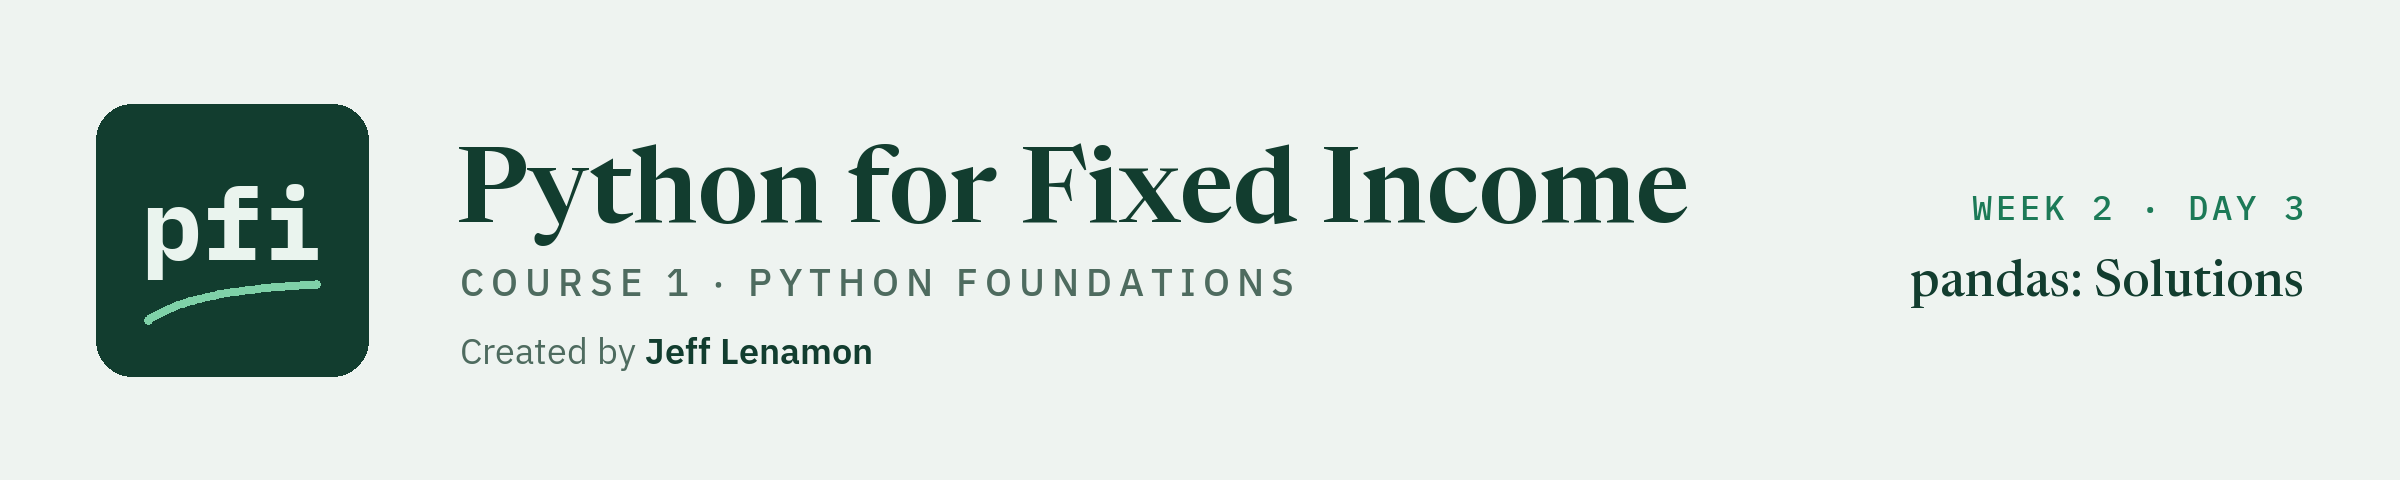

# pandas: Combining and Loading - Solutions

Week 2. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week2/day3/08_pandas_combining_and_loading_solutions.ipynb)

## Exercises

These are the worked answers to the exercises in the teaching notebook. They use the holdings file, the benchmark file, and the rating scale, with questions the lesson did not ask. The issuers are invented.

Each answer is followed by the check cell from the teaching notebook.

Run the next cell first. It imports pandas, loads fresh copies of the three files as `holdings`, `ratings`, and `benchmark`, and defines `check`, a small function that marks your answers. It allows for tiny rounding differences in numbers with a decimal point.

In [1]:
import os

import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if getattr(answer, 'ndim', 0) > 0 and not isinstance(expected, list):
        # a whole column or table was stored where a single value is expected
        print(label + ': not yet. A single value is expected, and you have a column or a table.')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of three files. In Colab they are read from GitHub.
if os.path.exists('../../../data/holdings.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')
benchmark = pd.read_csv(data_folder + 'benchmark.csv')
print(holdings.shape, ratings.shape, benchmark.shape)

(200, 19) (18, 4) (821, 19)


### Exercise 1

Q. Merge the benchmark with the rating scale. How many benchmark bonds are High Yield, and what is their total weight in the benchmark, in percent, rounded to one decimal place? Store the answers in **ex1_count** and **ex1_weight**.

In [2]:
# every benchmark bond has a rating, so the rating is the key
benchmark_rated = pd.merge(benchmark, ratings, on='rating')
# the row count should not change
print('Rows:', benchmark.shape[0], 'in,', benchmark_rated.shape[0], 'out')

# True where the bond is high yield
is_hy = benchmark_rated['grade'] == 'High Yield'

ex1_count = is_hy.sum()
ex1_weight = round(benchmark_rated.loc[is_hy, 'weight_pct'].sum(), 1)

print('High yield bonds in the benchmark:', ex1_count)
print('Their weight:', ex1_weight)

Rows: 821 in, 821 out
High yield bonds in the benchmark: 281
Their weight: 34.4


* 821 rows in and 821 out, so the merge kept every bond. 281 of them are High Yield, and they carry 34.4 percent of the benchmark's weight.

In [3]:
check('Exercise 1 count', ex1_count, 281)
check('Exercise 1 weight', ex1_weight, 34.4)

Exercise 1 count: correct
Exercise 1 weight: correct


### Exercise 2

Q. Merge the holdings with the rating scale, and total the face held in each rating bucket. How much face does the desk hold in the BBB bucket? Which three buckets have the most face, largest first? Store the answers in **ex2_bbb_face** and, as a list, in **ex2_top_buckets**.

In [4]:
# bring the bucket and the grade into the holdings
book = pd.merge(holdings, ratings, on='rating')

# face held, added up within each bucket
bucket_face = book.groupby('bucket')['par_held'].sum()
ex2_bbb_face = bucket_face.loc['BBB']
print('Face in the BBB bucket:', ex2_bbb_face)

# sort the grouped result, keep the top three, and take the bucket names from the index
top_three = bucket_face.sort_values(ascending=False).head(3)
ex2_top_buckets = top_three.index.tolist()
print(top_three)

Face in the BBB bucket: 151750000
bucket
BBB    151750000
A      147500000
BB     111750000
Name: par_held, dtype: int64


* 151,750,000 of face in the BBB bucket, which is the largest. The A bucket follows with 147,500,000, then BB with 111,750,000.

In [5]:
check('Exercise 2 BBB face', ex2_bbb_face, 151750000)
check('Exercise 2 top buckets', ex2_top_buckets, ['BBB', 'A', 'BB'])

Exercise 2 BBB face: correct
Exercise 2 top buckets: correct


### Exercise 3

Q. Keep the High Yield bonds of the holdings. What is their market-value-weighted average OAS, and their market-value-weighted average duration? Round both to two decimal places and store them in **ex3_hy_oas** and **ex3_hy_duration**.

In [6]:
# the grade comes from the rating scale
book = pd.merge(holdings, ratings, on='rating')
hy = book[book['grade'] == 'High Yield']

# sum of value times weight, divided by the sum of the weights
hy_value = hy['market_value'].sum()
ex3_hy_oas = round((hy['oas'] * hy['market_value']).sum() / hy_value, 2)
ex3_hy_duration = round((hy['duration'] * hy['market_value']).sum() / hy_value, 2)

print('High yield bonds:', hy.shape[0])
print('Weighted average OAS:', ex3_hy_oas)
print('Weighted average duration:', ex3_hy_duration)

High yield bonds: 72
Weighted average OAS: 334.73
Weighted average duration: 5.43


* The 72 high yield bonds have a weighted average OAS of 334.73 basis points and a weighted average duration of 5.43 years. The simple averages are 339.38 and 5.74, so weighting by market value lowers both.

In [7]:
check('Exercise 3 OAS', ex3_hy_oas, 334.73)
check('Exercise 3 duration', ex3_hy_duration, 5.43)

Exercise 3 OAS: correct
Exercise 3 duration: correct


### Exercise 4

Q. Convert the maturity column of the holdings to dates. How many bonds mature in the years 2040 to 2049? What is the CUSIP of the bond with the latest maturity date? Store the answers in **ex4_count** and **ex4_last_cusip**.

In [8]:
# text to dates, then the year of each date
holdings['maturity'] = pd.to_datetime(holdings['maturity'])
maturity_year = holdings['maturity'].dt.year

# both conditions must hold, so combine them with &
in_2040s = (maturity_year >= 2040) & (maturity_year <= 2049)
ex4_count = in_2040s.sum()
print('Bonds maturing in 2040 to 2049:', ex4_count)

# sort with the latest date first, and take the CUSIP of the first row
latest_first = holdings.sort_values('maturity', ascending=False)
ex4_last_cusip = latest_first['cusip'].iloc[0]
print('Latest maturity:', ex4_last_cusip)

latest_first[['cusip', 'ticker', 'coupon', 'maturity']].head(3)

Bonds maturing in 2040 to 2049: 17
Latest maturity: 99111HAB6


,cusip,ticker,coupon,maturity
189,99111HAB6,XANE,5.75,2056-08-23
153,99124UAE6,THAL,8.00,2056-03-15
184,99074WAD4,WYXA,6.75,2056-02-23


* 17 bonds mature in the 2040s. The latest maturity is the XANE 5.75% of 2056-08-23, CUSIP 99111HAB6.

In [9]:
check('Exercise 4 count', ex4_count, 17)
check('Exercise 4 last CUSIP', ex4_last_cusip, '99111HAB6')

Exercise 4 count: correct
Exercise 4 last CUSIP: correct


### Exercise 5

Exercise 3 worked out two weighted averages with the same two steps. A function holds the steps once, and runs them on any column, on any table, and on next month's file.

Q. Write a function `weighted_average(table, value_column, weight_column)` that takes a table and the names of two of its columns, and returns the average of the first column weighted by the second, rounded to two decimal places. The first line and the docstring are given. Replace the `...` in the body with your code, and end it with `return`. Then call it to find the market-value-weighted average coupon of the whole holdings file, and store the answer in **ex5_coupon**.

In [10]:
def weighted_average(table, value_column, weight_column):
    """
    Take a table, the name of the column to average, and the name of the column of weights,
    and return the weighted average, rounded to two decimal places.
    """
    # sum of value times weight, divided by the sum of the weights
    total = (table[value_column] * table[weight_column]).sum()
    return round(total / table[weight_column].sum(), 2)


# the same function, called for two columns of the holdings
ex5_coupon = weighted_average(holdings, 'coupon', 'market_value')
print(f'Weighted average coupon: {ex5_coupon:.2f} percent')
print(f"Weighted average OAS: {weighted_average(holdings, 'oas', 'market_value'):.2f} basis points")

Weighted average coupon: 5.95 percent
Weighted average OAS: 180.46 basis points


* 5.95 percent for the coupon, and 180.46 basis points for the OAS, the figure from section 8.7 of the lesson.
* The column names arrive as text, so `table[value_column]` picks whichever column was asked for. One function covers OAS, duration, coupon, and any weight.
* On the high yield rows alone, `weighted_average(hy, 'oas', 'market_value')` returns the 334.73 of Exercise 3.

In [11]:
# the first check calls your function on the holdings
check('Exercise 5 OAS', weighted_average(holdings, 'oas', 'market_value'), 180.46)
check('Exercise 5 coupon', ex5_coupon, 5.95)

Exercise 5 OAS: correct
Exercise 5 coupon: correct


### Exercise 6: AI check

You ask an AI assistant for the market-value-weighted average OAS of the desk's High Yield bonds. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It contains one bug.

Q. Read the code before you run it. What number do you expect? You worked it out yourself in Exercise 3. Then run the code. Does it agree with you?

* The answer from Exercise 3 is 334.73 basis points. The original code printed 339.38, with no error.
* The bug was the last step. The code merged and filtered correctly, then took `hy['oas'].mean()`, which is the simple average: every bond counts the same, whatever its size. The comment said 'weighted' and the code never used `market_value`.
* 339.38 is a believable spread for high yield bonds, and it is under 5 basis points from the right answer. Nothing about the number looks wrong. Two checks catch it: a figure worked out independently, and reading the code for the column that a weighted average must use.

In [12]:
# bring in the grade and keep the high yield bonds
book = pd.merge(holdings, ratings, on='rating')
hy = book[book['grade'] == 'High Yield']

# weighted average: sum of OAS times market value, divided by the sum of market value
ex6_hy_oas = round((hy['oas'] * hy['market_value']).sum() / hy['market_value'].sum(), 2)

print(f'Weighted average OAS of the High Yield bonds: {ex6_hy_oas}')

Weighted average OAS of the High Yield bonds: 334.73


In [13]:
check('Exercise 6 OAS', ex6_hy_oas, 334.73)

Exercise 6 OAS: correct
